# 无标度引力模型（5km）

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
import math
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
from math import sin, asin, cos, radians, fabs, sqrt
EARTH_RADIUS=6371 
def hav(theta):
    s = sin(theta / 2)
    return s * s
def get_distance_hav(lat0, lng0, lat1, lng1):    #lat纬度
    lat0 = radians(lat0)
    lat1 = radians(lat1)
    lng0 = radians(lng0)
    lng1 = radians(lng1)
    dlng = fabs(lng0 - lng1)
    dlat = fabs(lat0 - lat1)
    h = hav(dlat) + cos(lat0) * cos(lat1) * hav(dlng)
    distance = 2 * EARTH_RADIUS * asin(sqrt(h))
    return distance

In [3]:
pa=(np.load("5kmpa(bj).npy")).tolist()
pb=(np.load("5kmpb(bj).npy")).tolist()
ww=(np.load("5kmww(bj).npy")).tolist()
T_total2=(np.load("5kmT(bj).npy")).tolist()

In [4]:
dataframe=pd.DataFrame(columns=["Pa","Pb","d","T"])
dataframe["Pa"]=pd.Series(pa)
dataframe["Pb"]=pd.Series(pb)
dataframe["d"]=pd.Series(ww)
dataframe["T"]=pd.Series(T_total2)

In [5]:
dataframe1=dataframe[dataframe["Pa"]!=0]   
dr1=dataframe1[dataframe1["Pb"]!=0]

In [6]:
pa=(dr1.Pa).tolist()
pb=(dr1.Pb).tolist()
ww=(dr1.d).tolist()
T_total2=(dr1["T"]).tolist()

In [7]:
dis=[]   #无标度d
for i in ww:
    dis.append(round(i/5))

In [8]:
pa_=[]
for i in range(0,len(pa)):
    z=pa[i]
    if (z!=0):
        z1=math.log10(z)
        pa_.append(z1)
    else:
        z1=0
        pa_.append(z1)

In [9]:
pb_=[]
for i in range(0,len(pb)):
    z=pb[i]
    if (z!=0):
        z1=math.log10(z)
        pb_.append(z1)
    else:
        z1=0
        pb_.append(z1)

In [10]:
dis_=[]
for i in range(0,len(dis)):
    z=dis[i]
    if (z!=0):
        z1=math.log10(z)
        dis_.append(z1)
    else:
        z1=0
        dis_.append(z1)

In [11]:
logT=[]
for i in range(0,len(T_total2)):
    z=T_total2[i]
    if (z!=0):
        z1=math.log10(z)
        logT.append(z1)
    else:
        z1=0
        logT.append(z1)

In [12]:
data=[]
for i in range(0,len(pa_)):
    c=[]
    z1=pa_[i]
    z2=pb_[i]
    z3=dis_[i]
    #z4=logT[i]
    c.append(z1)
    c.append(z2)
    c.append(z3)
    #c.append(z4)
    data.append(c)

In [13]:
x=data
y=logT

In [14]:
regr = linear_model.LinearRegression()
regr.fit(x, y)
 
print ("x的系数值a：")
con_a=regr.coef_
print (regr.coef_)

print ("截距b:")
con_b=regr.intercept_
print (regr.intercept_)

yPred = regr.predict(x)

x的系数值a：
[ 0.66999878  0.63857064 -4.48642462]
截距b:
-4.547667852465788


In [15]:
constant=10**con_b
constant

2.8335582668986873e-05

In [16]:
alpha_pa=[]  #pa的阿尔法
for i in range(0,len(pa)):
    z=pa[i]**con_a[0]
    alpha_pa.append(z)


In [17]:
alpha_pb=[]
for i in range(0,len(pb)):
    z=pb[i]**con_a[1]
    alpha_pb.append(z)

In [18]:
alpha_dis=[]
for i in range(0,len(dis)):
    z=dis[i]**-con_a[2]
    alpha_dis.append(z)

In [19]:
model=[]
for i  in range(0,len(alpha_pa)):
    z=constant*alpha_pa[i]*alpha_pb[i]/alpha_dis[i]
    model.append(z)

In [21]:
def get_lr_stats(x, y, model):
    #message0 = '一元线性回归方程为: '+'\ty' + '=' + str(model.intercept_)+' + ' +str(model.coef_[0]) + '*x'
    from scipy import stats
    n = len(x)
    y_prd = regr.predict(x)
    Regression = sum((y_prd - np.mean(y))**2) # 回归平方和
    Residual   = sum((y - y_prd)**2)          # 残差平方和
    total = sum((y-np.mean(y))**2) #总体平方和
    R_square   = 1-Residual / total # 相关性系数R^2
    message1 = ('相关系数(R^2)： ' + str(R_square) + '；' + '\n'+ '总体平方和(TSS)： ' +  str(total) + '；' + '\n')
    message2 = ('回归平方和(RSS)： ' + str(Regression) + '；' + '\n残差平方和(ESS)： ' +  str(Residual) + '；' + '\n')
    return print(message1 + message2 )
 
get_lr_stats(x,y,regr)



相关系数(R^2)： 0.5715789820168642；
总体平方和(TSS)： 1217.4333518536716；
回归平方和(RSS)： 695.8593159259101；
残差平方和(ESS)： 521.5740359277712；



In [22]:
model1=[]
for i in range(0,len(model)):
    z=model[i]
    if z!=0:
        
        z1=round(math.log10(z),1)
        model1.append(z1)
    else:
        model1.append(0)

In [23]:
ddtt=pd.DataFrame(columns=["model","T"])
ddtt["model"]=model1
ddtt["T"]=logT

In [24]:
ind=pd.Series(model1).value_counts().index
ind1=ind.tolist()
ind1.sort()

In [25]:
me=[]
sd=[]
for temp in ind1:
    dr=ddtt[ddtt["model"]==temp]
    a1=np.array(dr["T"])
    a2=np.mean(a1)
    me.append(a2)
    a3=np.std(a1)
    sd.append(a3)

In [27]:
def f_1(x, A, B):
    return A * x + B
x0 =model1
y0 =logT
A1, B1 = optimize.curve_fit(f_1, x0, y0)[0]
x1 = np.arange(min(model1),max(model1), 0.01)#30和75要对应x0的两个端点，0.01为步长
y1 = A1 * x1 + B1

In [28]:
print(A1)
print(B1)

0.9999499793196863
-0.0001585129459118484


In [31]:
#np.save('sd_fig4_5',sd)

In [29]:
x=[4.5,-4.5]
y=x

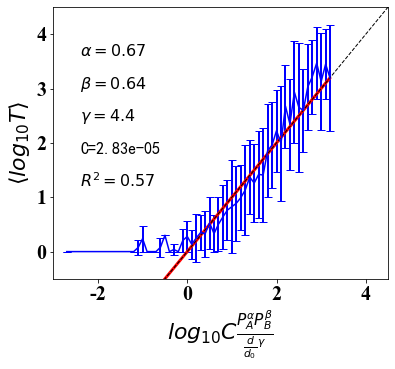

In [30]:
fig= plt.figure(figsize=(6,5))        #一个区域的出和进流量
ax = fig.add_subplot(1,1,1) 
#plt.scatter(model1,logT,marker = 's',color="w",linewidths=1,s=20,edgecolors='blue')
ax.errorbar(ind1,me,yerr=sd,fmt="-",color="blue",ecolor='blue',elinewidth=2,capsize=4)
plt.plot(x1,y1,color="red",linewidth=3)
plt.plot(x,y,linewidth=1,ls='--',color='black')
plt.text(-2.4, 3.6, r'$\alpha=0.67$',size=16)
plt.text(-2.4, 3., r'$\beta=0.64$',size=16)
plt.text(-2.4, 2.4, r'$\gamma=4.4$',size=16)
plt.text(-2.4, 1.8, 'C=2.83e-05',size=16)
plt.text(-2.4, 1.2, r'$R^2=0.57$',size=16)
#plt.scatter(popnu,intr,marker = 's',color="w",linewidths=1,s=20,edgecolors='red',label="Tin",alpha=0.6)
#plt.plot( eavd,eloc_num, marker='.',color="red",label="in_Tij",alpha=0.1)
#plt.legend(loc="best",prop={'size':20,'family':'Times New Roman'})
#ax.set_yscale("log")
#ax.set_xscale("log")
plt.ylim(-0.5,4.5)
plt.xlim(-3,4.5)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
ax.set_ylabel(r"$\langle log_{10}T \rangle$",size=22,family='Times New Roman')  
ax.set_xlabel(r"$log_{10}C\frac{P_A^\alpha P_B^\beta}{\frac{d}{d_0}^\gamma}$",size=22,family='Times New Roman')
plt.tick_params(labelsize=20)